In [37]:
# ! pip install yfinance
import Ab as ab
import datetime as dt
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Get data from yahoo finance
sd = dt.datetime(1998,12,4)
ed = dt.datetime(2025,8,2)
# 1x leveraged nasdaq 100 etf
qqq = ab.StockData('QQQ')
qqq.get_data_from_yfinance('QQQ', sd, ed)
# 2x leveraged nasdaq 100 etf
qld = ab.StockData('QLD')
qld.get_data_from_yfinance('QLD', sd, ed)
# 3x leveraged nasdaq 100 etf
tqqq = ab.StockData('TQQQ')
tqqq.get_data_from_yfinance('TQQQ', sd, ed)
#nasdaq 100 index
ndx = ab.StockData('NDX')
ndx.get_data_from_yfinance('NDX', sd, ed)
#S&P 500 etf
spy = ab.StockData('SPY')
spy.get_data_from_yfinance('SPY', sd, ed)
#nasdaq stocks above 200 day moving average percentage
naa200r = ab.StockData('NAA200R')
naa200r.get_data_from_csv('data/NAA200R.csv')

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [38]:
def naa200r_performance(ticker, sd, ed, signal_ma_window = 20, buy_threshold = 15 , sell_threshold = 30,  visualization=True):

    signal_data = naa200r.data.sort_index().loc[sd:ed].copy()
    ticker_data = ticker.data.sort_index().loc[sd:ed].copy()
    ticker_name = ticker.ticker

    threshold_strategy = ab.Threshold(name = 'NAA200R',
                                    buy_threshold = buy_threshold , sell_threshold = sell_threshold ,
                                    signal_ma_window=signal_ma_window )

    # run strategy
    threshold_strategy.run_strategy(naa200r, sd , ed)
    naa200r_threshold_bt = ab.BackTest()
    naa200r_threshold_bt.run_backtest(threshold_strategy, ticker, sd , ed)
    print(naa200r_threshold_bt.performance_summary())


    if visualization == True:

        # get trade list
        df_balance = naa200r_threshold_bt.balance
        df_balance['Trade'] = np.where(df_balance['Stock'].diff()>0, 1, np.where(df_balance['Stock'].diff()<0, -1, 0))

        # Calculate 10 years ago from end date for plotting
        plot_start_date = ed - dt.timedelta(days=365*10)

        # Filter data for plotting (last 10 years only)
        signal_data_plot = signal_data.loc[plot_start_date:ed]
        ticker_data_plot = ticker_data.loc[plot_start_date:ed]
        df_balance_plot = df_balance.loc[plot_start_date:ed]

        # plots
        fig = plt.figure(figsize=(16,4))
        signal_data_plot['Close'].plot(label='NAA200R')
        signal_data_plot['Close'].rolling(signal_ma_window).mean().plot(label='NAA200R MA{}'.format(signal_ma_window))


        plt.axhline(y = 15, color = 'black', linestyle='dashed')
        plt.axhline(y = 30, color = 'black', linestyle='dashed')

        trades = df_balance_plot.loc[df_balance_plot['Trade']!=0]
        for idx, row in trades.iterrows():
            if row['Trade']<0:
                plt.axvline(x=idx, color = 'red', linestyle='dashed')
            if row['Trade']>0:
                plt.axvline(x=idx, color = 'green', linestyle='dashed')

        plt.ylim([0, 50])
        plt.title('Trading Signals And NAA200R (Last 10 Years)')
        plt.legend()
        plt.show()

        fig = plt.figure(figsize=(16,4))
        ticker_data_plot['Close'].plot()

        trades = df_balance_plot.loc[df_balance_plot['Trade']!=0]
        for idx, row in trades.iterrows():
            if row['Trade']<0:
                plt.axvline(x=idx, color = 'red', linestyle='dashed')
            if row['Trade']>0:
                plt.axvline(x=idx, color = 'green', linestyle='dashed')
        plt.title('Trading Signals And {} (Last 10 Years)'.format(ticker_name))
        plt.show()

        fig = plt.figure(figsize=(16,4))
        df_balance_plot.plot(y = 'Total', title = 'Portfolio Performance of {} (Last 10 Years)'.format(ticker_name), figsize=(16,4))

        # Display detailed trading records table
        print("\n" + "="*90)
        print("DETAILED TRADING RECORDS")
        print("="*90)

        # Calculate NAA200R SMA for the entire period
        signal_data_sma = signal_data['Close'].rolling(signal_ma_window).mean()

        # Get all trades (buy and sell signals)
        all_trades = df_balance.loc[df_balance['Trade']!=0].copy()

        if len(all_trades) > 0:
            # Create detailed trading table
            trading_records = []

            for idx, row in all_trades.iterrows():
                trade_type = "BUY" if row['Trade'] > 0 else "SELL"
                naa200r_value = signal_data.loc[idx, 'Close'] if idx in signal_data.index else 'N/A'
                naa200r_sma_value = signal_data_sma.loc[idx] if idx in signal_data_sma.index else 'N/A'
                ticker_price = ticker_data.loc[idx, 'Close'] if idx in ticker_data.index else 'N/A'

                trading_records.append({
                    'Date': idx.strftime('%Y-%m-%d'),
                    'Action': trade_type,
                    'NAA200R': f"{naa200r_value:.2f}" if naa200r_value != 'N/A' else 'N/A',
                    f'NAA200R MA{signal_ma_window}': f"{naa200r_sma_value:.2f}" if naa200r_sma_value != 'N/A' else 'N/A',
                    f'{ticker_name} Price': f"${ticker_price:.2f}" if ticker_price != 'N/A' else 'N/A',
                    'Cash': f"${row['Cash']:.2f}",
                    'Stock Value': f"${row['Stock']:.2f}",
                    'Total Portfolio': f"${row['Total']:.2f}"
                })

            # Convert to DataFrame and display
            trades_df = pd.DataFrame(trading_records)
            print(trades_df.to_string(index=False))

            # Summary statistics
            buy_trades = len(trades_df[trades_df['Action'] == 'BUY'])
            sell_trades = len(trades_df[trades_df['Action'] == 'SELL'])

            print(f"\nTrading Summary:")
            print(f"Total Trades: {len(trades_df)}")
            print(f"Buy Signals: {buy_trades}")
            print(f"Sell Signals: {sell_trades}")

        else:
            print("No trades executed during this period.")

        print("="*90)


NAA200R 15/50 MA 50:
cumulative return      : 1198.14%
compound anual return  : 26.2441%
max_drawdown           : -53.49%
sharp_ratio            : 5.08%
average of daily return: 0.1288%
std of daily return    : 2.5374%
number of trades       : 70,
trading days           : 3864,
batting Average        : 42.03%
Gain Average           : 19.08%
Loss Average           : -4.90%
Risk Reward Ratio      : 3.89
Gain STD               : 21.99%
Loss STD               : 5.91%
            
None


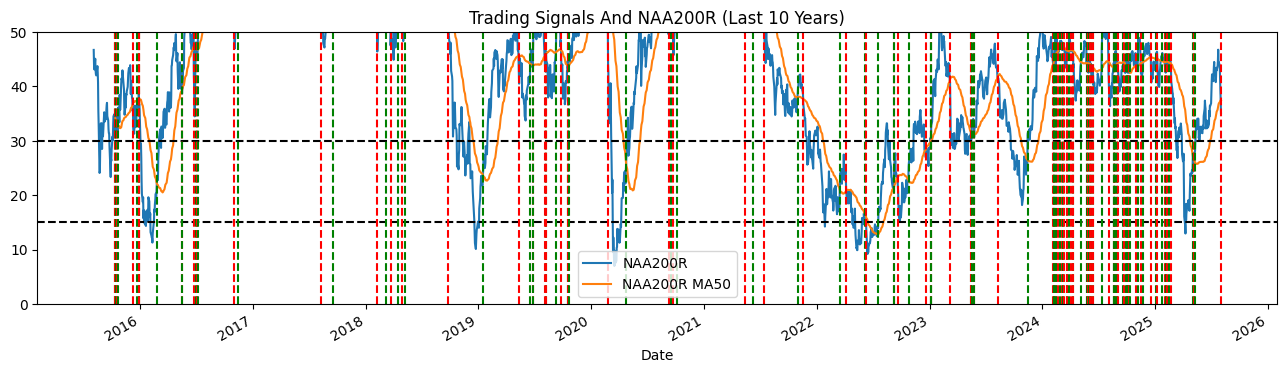

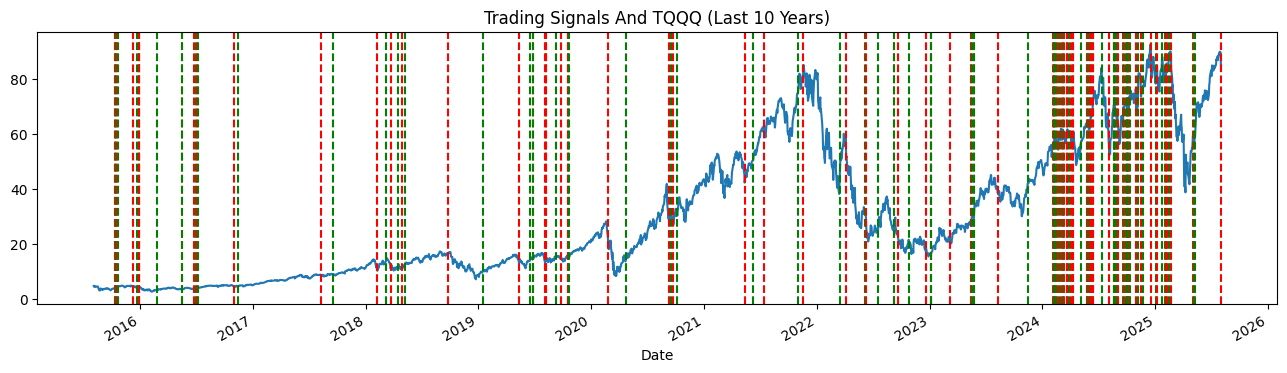


DETAILED TRADING RECORDS
      Date Action NAA200R NAA200R MA50 TQQQ Price   Cash Stock Value Total Portfolio
2015-02-05    BUY   51.98          nan      $3.90  $0.00       $0.26           $1.00
2015-07-08   SELL   47.93        56.42      $4.11  $1.05       $0.00           $1.05
2015-10-12    BUY   34.95        34.75      $4.01  $0.00       $0.26           $1.05
2015-10-13   SELL   32.77        34.46      $3.93  $1.03       $0.00           $1.03
2015-10-15    BUY   35.60        33.92      $4.11  $0.00       $0.25           $1.03
2015-10-21   SELL   31.57        33.14      $4.10  $1.03       $0.00           $1.03
2015-10-22    BUY   33.44        32.96      $4.34  $0.00       $0.24           $1.03
2015-12-09   SELL   35.47        36.73      $4.67  $1.11       $0.00           $1.11
2015-12-24    BUY   37.58        37.48      $4.64  $0.00       $0.24           $1.11
2015-12-28   SELL   36.22        37.49      $4.64  $1.11       $0.00           $1.11
2015-12-29    BUY   38.78        37.56 

<Figure size 1600x400 with 0 Axes>

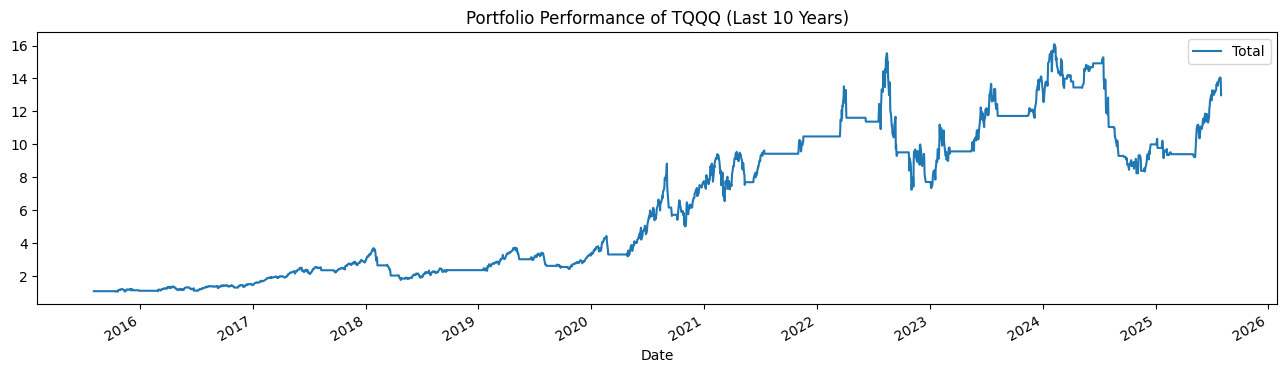

In [39]:

sd = dt.datetime(2015,1,1)
ed = dt.datetime(2025,8,2)
signal_ma_window = 50
buy_threshold = 15
sell_threshold = 50
ticker = tqqq

naa200r_performance(ticker, sd, ed, signal_ma_window, buy_threshold , sell_threshold,  visualization=True)


NAA200R 15/30 MA 20:
cumulative return      : 4149.10%
compound anual return  : 40.6135%
max_drawdown           : -59.61%
sharp_ratio            : 5.96%
average of daily return: 0.1953%
std of daily return    : 3.2749%
number of trades       : 26,
trading days           : 3864,
batting Average        : 44.00%
Gain Average           : 95.92%
Loss Average           : -11.02%
Risk Reward Ratio      : 8.71
Gain STD               : 154.00%
Loss STD               : 5.12%
            
None


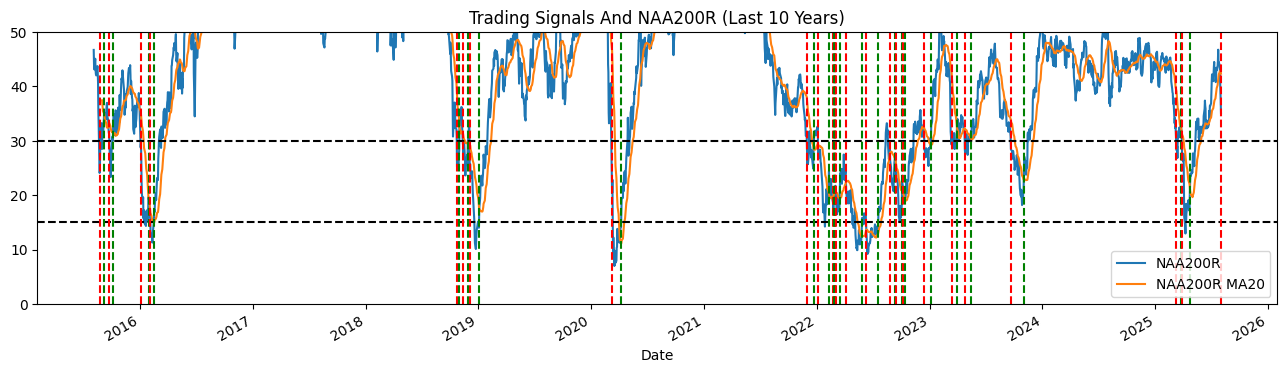

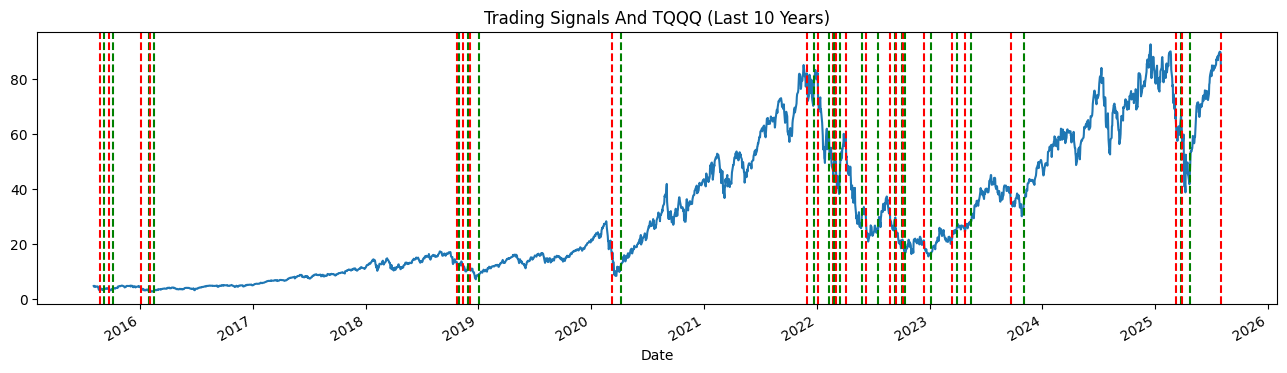


DETAILED TRADING RECORDS
      Date Action NAA200R NAA200R MA20 TQQQ Price   Cash Stock Value Total Portfolio
2015-08-24   SELL   24.09        42.49      $3.23  $0.84       $0.00           $0.84
2015-09-08    BUY   35.24        34.98      $3.84  $0.00       $0.22           $0.84
2015-09-25   SELL   29.10        33.13      $3.62  $0.79       $0.00           $0.79
2015-10-07    BUY   32.91        31.37      $3.88  $0.00       $0.20           $0.79
2016-01-04   SELL   28.76        35.47      $4.28  $0.87       $0.00           $0.87
2016-02-01    BUY   18.85        18.84      $3.61  $0.00       $0.24           $0.87
2016-02-02   SELL   16.34        18.22      $3.38  $0.82       $0.00           $0.82
2016-02-16    BUY   15.29        15.06      $3.16  $0.00       $0.26           $0.82
2018-10-24   SELL   25.25        38.48     $11.71  $3.02       $0.00           $3.02
2018-11-01    BUY   33.07        32.61     $13.04  $0.00       $0.23           $3.02
2018-11-12   SELL   29.43        31.56 

<Figure size 1600x400 with 0 Axes>

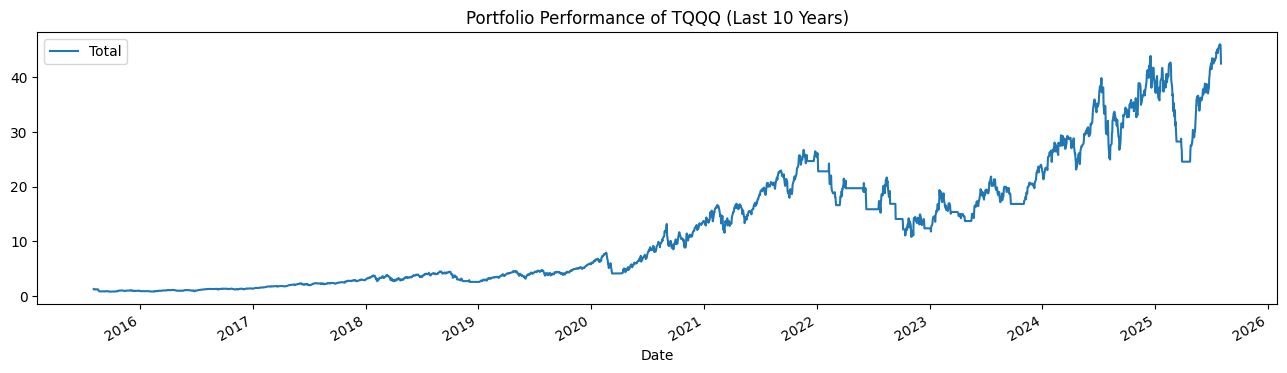

In [40]:
sd = dt.datetime(2015,1,1)
ed = dt.datetime(2025,8,2)
signal_ma_window = 20
buy_threshold = 15
sell_threshold = 30
ticker = tqqq

naa200r_performance(ticker, sd, ed, signal_ma_window, buy_threshold , sell_threshold,  visualization=True)


NAA200R 30/30 MA 50:
cumulative return      : 343.18%
compound anual return  : 14.4932%
max_drawdown           : -20.65%
sharp_ratio            : 6.16%
average of daily return: 0.0609%
std of daily return    : 0.9894%
number of trades       : 13,
trading days           : 3864,
batting Average        : 66.67%
Gain Average           : 26.43%
Loss Average           : -5.48%
Risk Reward Ratio      : 4.83
Gain STD               : 28.61%
Loss STD               : 4.13%
            
None


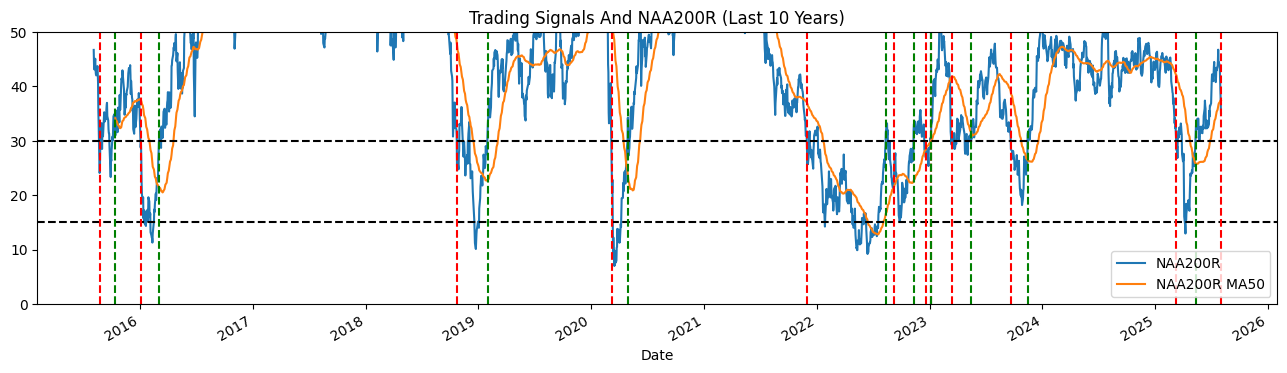

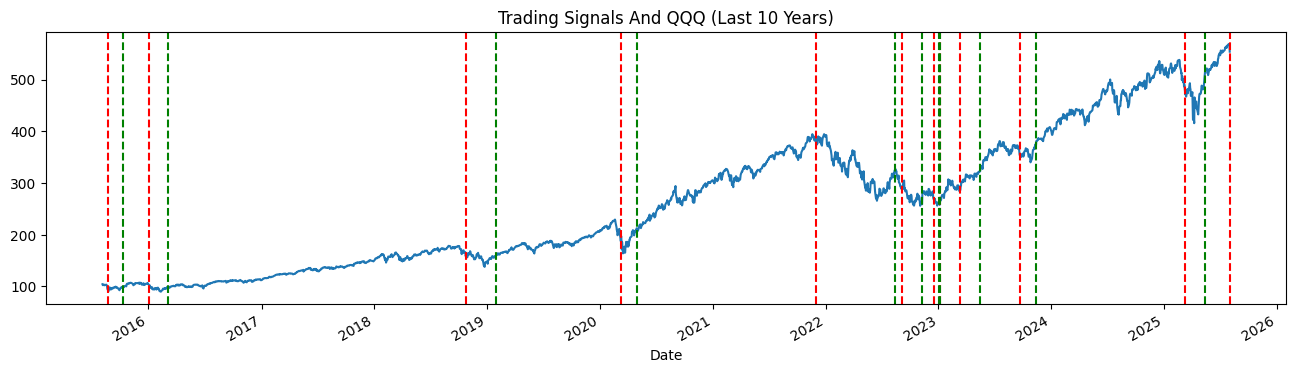


DETAILED TRADING RECORDS
      Date Action NAA200R NAA200R MA50 QQQ Price  Cash Stock Value Total Portfolio
2015-02-05    BUY   51.98          nan    $95.77 $0.00       $0.01           $1.00
2015-08-24   SELL   24.09        49.35    $91.30 $0.95       $0.00           $0.95
2015-10-12    BUY   34.95        34.75    $99.27 $0.00       $0.01           $0.95
2016-01-04   SELL   28.76        37.58   $102.09 $0.98       $0.00           $0.98
2016-03-04    BUY   30.72        21.37    $98.52 $0.00       $0.01           $0.98
2018-10-24   SELL   25.25        47.63   $158.17 $1.57       $0.00           $1.57
2019-01-31    BUY   31.75        22.77   $161.33 $0.00       $0.01           $1.57
2020-03-09   SELL   20.40        52.86   $187.24 $1.83       $0.00           $1.83
2020-04-29    BUY   34.23        23.83   $212.29 $0.00       $0.01           $1.83
2021-11-30   SELL   28.03        36.98   $384.46 $3.31       $0.00           $3.31
2022-08-12    BUY   31.47        16.63   $323.97 $0.00       

<Figure size 1600x400 with 0 Axes>

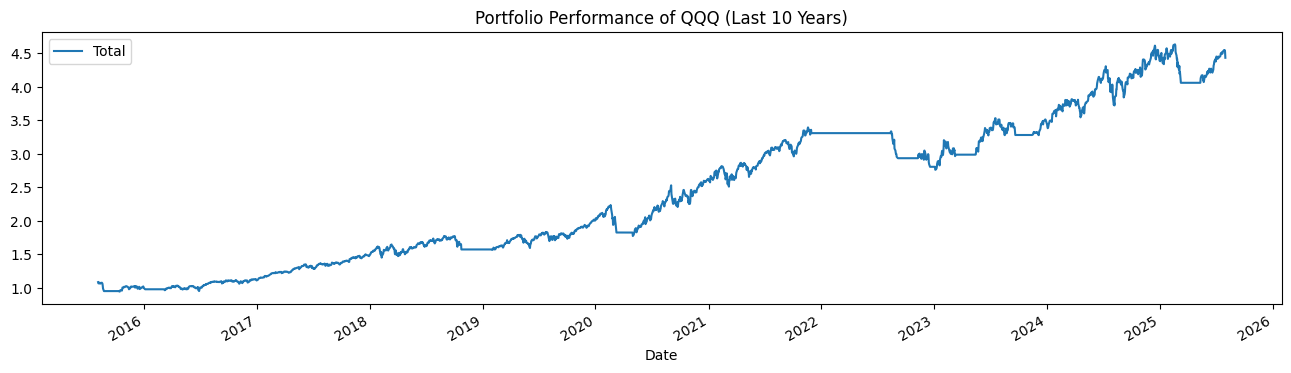

In [41]:
sd = dt.datetime(2015,1,1)
ed = dt.datetime(2025,8,2)
signal_ma_window = 50
buy_threshold = 30
sell_threshold = 30
ticker = tqqq

naa200r_performance(qqq, sd, ed, signal_ma_window, buy_threshold , sell_threshold,  visualization=True)

/tmp/ipykernel_88500/2331330349.py:3: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  plt.plot(naa200r.data.sort_index()[['Close']].rolling(20).mean(), label='MA20')


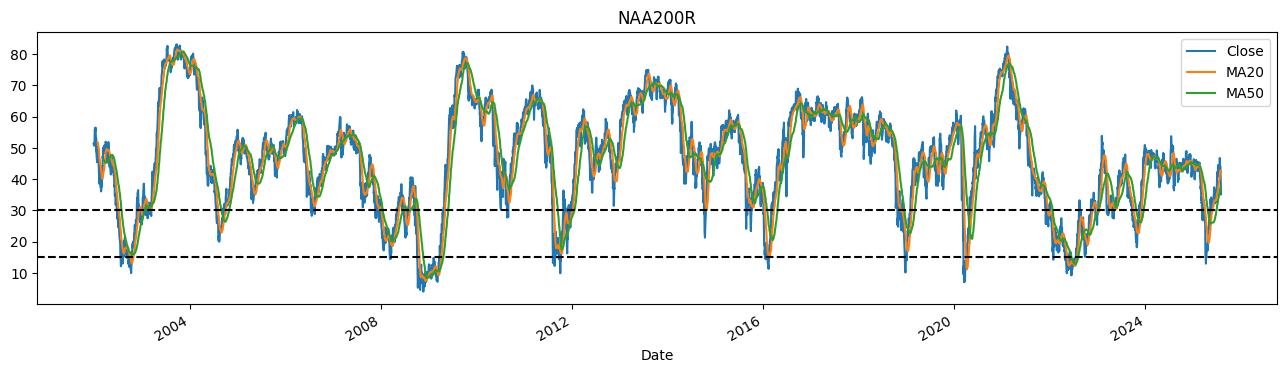

<Axes: xlabel='Date'>

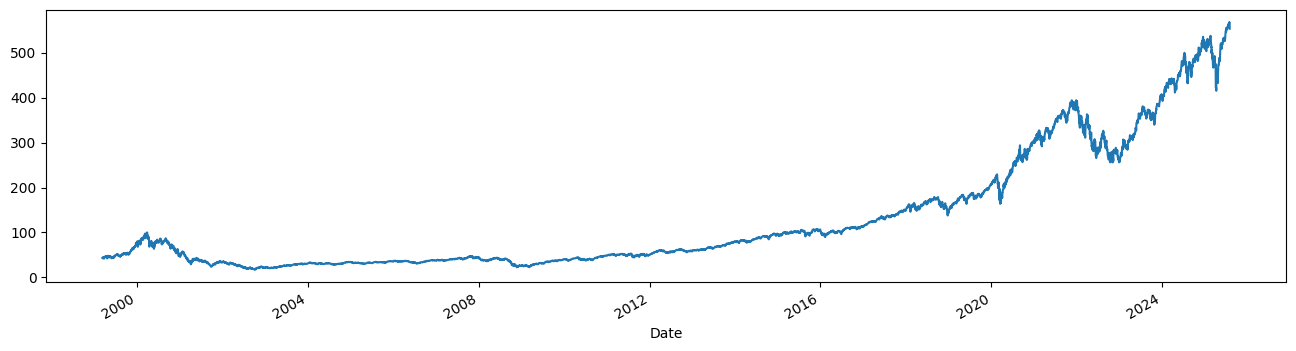

In [42]:
fig = plt.figure(figsize=(16,4))
naa200r.data.sort_index()['Close'].plot(title='NAA200R')
plt.plot(naa200r.data.sort_index()[['Close']].rolling(20).mean(), label='MA20')
plt.plot(naa200r.data.sort_index()[['Close']].rolling(50).mean(), label='MA50')

plt.axhline(y = 15, color = 'black', linestyle='dashed')
plt.axhline(y = 30, color = 'black', linestyle='dashed')
plt.legend()
plt.show()


qqq.data.sort_index()['Close'].plot(figsize=(16,4))
